# 5R1C zone with a heat pump - fixed setpoint vs comfort band

One winter week of real weather. The same system is solved twice: once held at
exactly 21 degC, once allowed to float between 20 and 22 degC.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from esmkit import SystemSpec, build_system, node_results, objective_value, solve

In [2]:
params = json.load(open("../test/data/golden/zone_params_168h.json"))
frame = pd.read_csv(
    "../test/data/golden/zone_inputs_168h.csv", index_col=0, parse_dates=True
)
frame.index = frame.index.tz_convert("Europe/Berlin")
index = frame.index

print(index[0], "->", index[-1], " ", len(index), "steps")
print(params)

2010-01-01 00:30:00+01:00 -> 2010-01-07 23:30:00+01:00   168 steps
{'C_m': 8.421875, 'H': {'Floor': 0.06712307692307692, 'Roof': 0.091565, 'Ventilation': 0.08714475000000002, 'Walls': 0.17755, 'Windows': 0.095788}, 'H_door': 0.006, 'H_is': 2.6897062500000004, 'H_ms': 3.9414375, 'design_capacity': 20.169597874442307, 'max_load': 20.16959787444231}


Carnot COP towards a 35 degC sink at 40 % of the ideal, clipped to 1.5 - 6.

In [3]:
cop = np.clip(0.40 * (35 + 273.15) / np.maximum(35.0 - frame["T_e"].to_numpy(), 1.0), 1.5, 6.0)
price = np.where((index.hour >= 17) & (index.hour < 21), 0.60, 0.20)

print("COP  min {:.2f}  mean {:.2f}  max {:.2f}".format(cop.min(), cop.mean(), cop.max()))

COP  min 2.55  mean 3.26  max 3.80


In [4]:
spec = SystemSpec()
spec.add_bus("elec", carrier="electricity")
spec.add_bus("heat", carrier="heat")

spec.add_component("power", "source", bus="elec", price="@price")
spec.add_component("hp", "heat_pump", bus_in="elec", bus_out="heat", cop="@cop")
spec.add_component(
    "zone",
    "zone5r1c",
    heat_bus="heat",
    T_e="@T_e",
    gain_mass="@gain_mass",
    gain_surface="@gain_surface",
    comfort_lb="@comfort_lb",
    comfort_ub="@comfort_ub",
    C_m=params["C_m"],
    H=params["H"],
    H_door=params["H_door"],
    H_is=params["H_is"],
    H_ms=params["H_ms"],
    max_load=params["max_load"],
    design_capacity=params["design_capacity"],
)

base_inputs = {
    "price": price,
    "cop": cop,
    "T_e": frame["T_e"].to_numpy(),
    "gain_mass": frame["gain_mass"].to_numpy(),
    "gain_surface": frame["gain_surface"].to_numpy(),
}

spec

SystemSpec(2 buses, 3 components)

In [5]:
inputs_fixed = dict(base_inputs)
inputs_fixed["comfort_lb"] = np.full(len(index), 21.0)
inputs_fixed["comfort_ub"] = np.full(len(index), 21.0)

es, nodes = build_system(spec, inputs_fixed, index)
model_fixed, _ = solve(es)
results_fixed = node_results(model_fixed, nodes, index=index)
zone_fixed = results_fixed["zone"]["timeseries"]

In [6]:
inputs_band = dict(base_inputs)
inputs_band["comfort_lb"] = np.full(len(index), 20.0)
inputs_band["comfort_ub"] = np.full(len(index), 22.0)

es, nodes = build_system(spec, inputs_band, index)
model_band, _ = solve(es)
results_band = node_results(model_band, nodes, index=index)
zone_band = results_band["zone"]["timeseries"]

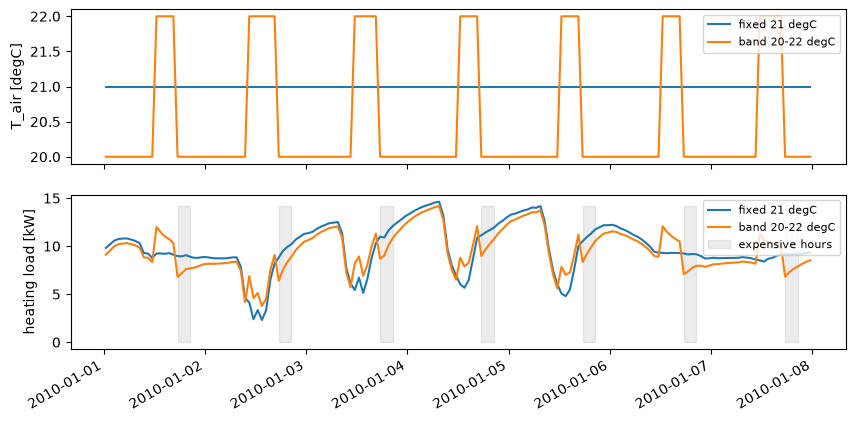

In [7]:
fig, (ax_t, ax_q) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax_t.plot(index, zone_fixed["T_air"], label="fixed 21 degC")
ax_t.plot(index, zone_band["T_air"], label="band 20-22 degC")
ax_t.set_ylabel("T_air [degC]")
ax_t.legend(loc="upper right", fontsize=8)

ax_q.plot(index, zone_fixed["Heating Load"], label="fixed 21 degC")
ax_q.plot(index, zone_band["Heating Load"], label="band 20-22 degC")
ax_q.fill_between(index, 0, zone_band["Heating Load"].max(),
                  where=(index.hour >= 17) & (index.hour < 21),
                  color="grey", alpha=0.15, label="expensive hours")
ax_q.set_ylabel("heating load [kW]")
ax_q.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.show()

In [8]:
evening = (index.hour >= 17) & (index.hour < 21)

print("                        fixed 21     band 20-22")
print("heat delivered [kWh] : {:10.2f}   {:10.2f}".format(
    zone_fixed["Heating Load"].sum(), zone_band["Heating Load"].sum()))
print("electricity    [kWh] : {:10.2f}   {:10.2f}".format(
    results_fixed["hp"]["in_elec"].sum(), results_band["hp"]["in_elec"].sum()))
print("cost           [EUR] : {:10.2f}   {:10.2f}".format(
    objective_value(model_fixed), objective_value(model_band)))
print("heat in peak     [%] : {:10.1f}   {:10.1f}".format(
    100 * zone_fixed["Heating Load"].to_numpy()[evening].sum() / zone_fixed["Heating Load"].sum(),
    100 * zone_band["Heating Load"].to_numpy()[evening].sum() / zone_band["Heating Load"].sum()))
print()
print("max_load {:.2f} kW, peak load {:.2f} / {:.2f} kW".format(
    params["max_load"], zone_fixed["Heating Load"].max(), zone_band["Heating Load"].max()))
print("max_load_violation   : {:.2e}   {:.2e}".format(
    results_fixed["zone"]["max_load_violation"], results_band["zone"]["max_load_violation"]))

                        fixed 21     band 20-22
heat delivered [kWh] :    1649.34      1611.52
electricity    [kWh] :     523.80       510.38
cost           [EUR] :     140.30       131.75
heat in peak     [%] :       17.2         14.7

max_load 20.17 kW, peak load 14.63 / 14.17 kW
max_load_violation   : 0.00e+00   8.10e-16
